In [42]:
import jax
import jax.numpy as jnp
import optax
import flax.linen as nn
from flax.training import train_state
from flax.linen import initializers
from flax.training.common_utils import onehot
from flax.training import checkpoints
from flax import jax_utils
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
from itertools import islice, cycle
from flax.training.train_state import TrainState
from flax import struct
from typing import Union, Callable
from optax import tree_utils as otu

import sys
sys.path.append('../utils')

import datasets


jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


# MNIST Grokking 

We want to show that MNIST groks with some parameter and AdamW, but applying the different preconditioners it reduces the distances

## Data and model definition

We import the MNIST dataset and create the necessary generators and model structures; this doesn't change in the structure

In [2]:
# Don't use TFDS because SSL sometimes is dumb on site; use Jax loader instead
# https://github.com/jax-ml/jax/blob/main/examples/datasets.py

train_images, train_labels, test_images, test_labels = datasets.mnist()
train_images, train_labels, test_images, test_labels = jnp.array(train_images), jnp.array(train_labels), jnp.array(test_images), jnp.array(test_labels)

# np.random.seed(0)
# Create a generator that yields shuffled batches of data without repetition until an epoch is complete
def data_generator(images, labels, batch_size):
    num_samples = images.shape[0]
    # while True:
    #     # Shuffle the data at the beginning of each epoch
    indices = np.random.permutation(num_samples)
    # indices = np.arange(num_samples)
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield {'image': images[batch_indices], 'label': labels[batch_indices]}

In [3]:

# Model definition (Linen)
class MLP(nn.Module):
    depth: int
    width: int

    @nn.compact
    def __call__(self, x):
        for i in range(self.depth):
            if i == 0:
                x = nn.Dense(self.width,
                             dtype=jnp.float64,
                             kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784)),
                             bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784))
                            )(x)
            elif i == self.depth - 1:
                x = nn.Dense(10, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                                )(x)
            else:
                x = nn.Dense(self.width, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                            )(x)
            if i < self.depth - 1:
                x = nn.relu(x)
        return x



## Jax data structures

WE use a subclassed TrainState so that we can use more advanced optax transformations rather than just Adam/SGD etc. 

In [14]:

# The TrainState in Flax doesn't allow for more complex optimziers
# Thus we subclass it and insert the way we need to update 
class MyTrainState(TrainState):
    tx: optax.GradientTransformationExtraArgs = struct.field(pytree_node=False)
    def apply_gradients(self, *, grads, **kwargs):
        value, value_fn, x, labels = kwargs['value'], kwargs['value_fn'], kwargs['x'], kwargs['labels']
        updates, new_opt_state = self.tx.update(
            grads,
            self.opt_state,
            self.params,
            value=value,
            grad=grads,
            value_fn=value_fn,
            x=x,
            labels=labels
        )
        new_params_with_opt = optax.apply_updates(
            self.params, updates)
        return self.replace(
          step=self.step + 1,
          params=new_params_with_opt,
          opt_state=new_opt_state,
        )
        # print(new_params_with_opt)
    
def create_train_state(rng, model, learning_rate, weight_decay: float=1e-2, initialization_scale: float=1.0, 
                      optimizer: Union[str, optax._src.base.GradientTransformationExtraArgs] = 'adamw' ):
    params = model.init(rng, jnp.ones([1, 784], dtype=jnp.float64,))
    params = jax.tree.map(lambda p: initialization_scale * p, params)
    tx = optax.adamw(learning_rate, weight_decay=weight_decay)

    if optimizer == 'adamw':
        tx = optax.adamw(learning_rate, weight_decay=weight_decay)
    elif optimizer == 'adam':
        tx = optax.adam(learning_rate)
    elif optimizer == 'sgd':
        tx = optax.sgd(learning_rate)
    else: 
        print('Custom optimizer')
        tx = optimizer
        
    # tx = optax.chain(
    #     optax.sgd(learning_rate),
    #     optax.scale_by_backtracking_linesearch(max_backtracking_steps=5, decrease_factor=.5)
    # )
    return MyTrainState.create(apply_fn=model.apply, params=params, tx=tx)


## Parameters

These are parameters from the Omnigrok paper/Github repo. 

In [37]:
### Choose experiment parameters
train_points = 1000
optimization_steps = 100000
batch_size = 200
weight_decay = 0.01
lr = 1e-3
initialization_scale = 8.0
depth = 2             # the number of nn.Linear modules in the model
width = 250


## Training Loop

Make the training loop; we make two of them: one without any sort of precond operator, and the other with it. 
These should be transferrable; e.g. can move from one to the other using differing state

In [52]:
lamb = 2.0
if type(lamb) == float or type(lamb) == int:
    val = lamb
    lamb = lambda b: val
    
lamb(5)

2.0

In [35]:
def train_mnist_noprecond(model, state, optimization_steps: int=100000, trian_points: int=1000, 
                          batch_size: int = 200, log_freq: int = None):
    # Logs
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    log_steps = []
    losses = []
    norms = []

    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)
        return loss

    @jax.jit
    def batch_loss_accuracy(params, x, labels):
        # Eval model 
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)

        # Get accuracy 
        predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
        correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)

        return  loss, correct
        
    def compute_loss_and_accuracy(params, dataset):
        """Computes mean loss of `model` on `dataset`."""
        total_loss = 0
        total_points = 0
        correct = 0

        for batch in dataset:
            x, labels = batch['image'], batch['label']
        
            batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)

            total_loss += batch_loss
            correct += batch_accuracy
            total_points += x.shape[0]
        return total_loss / total_points, (correct / total_points)

    # For efficiency, calculate the gradient before hand
    grad_fn = jax.value_and_grad(loss_fn_wrapper)
    test_ds = data_generator(test_images, test_images, batch_size)

    steps = 0
    break_outer = False

    if not log_freq:
        log_freq = math.ceil(optimization_steps / 150)
    with tqdm(total=optimization_steps) as pbar:
        # Loop over each epoch (approximate total number of batch steps)
        for epoch in range(optimization_steps // (train_points // batch_size) + 1):

            # Recreate the training generator for each epoch for shuffle
            train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
            for batch in train_ds:
                x, labels = batch['image'], batch['label']

                # Store the 
                if (steps < 15) or (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0):
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                    )
                    train_losses.append(
                        epoch_loss
                    )
                    train_accuracies.append(
                        epoch_acc
                    )
        
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(test_images, test_labels, batch_size=50)
                    )
                    test_losses.append(
                        epoch_loss
                    )
                    test_accuracies.append(
                        epoch_acc
                    )
        
                    log_steps.append(steps)
                    params_leaves = jax.tree_util.tree_leaves(state.params)
                    norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                    # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                
                loss, grads = grad_fn(state.params, x, labels)   
                losses.append(loss)
    
                state = state.apply_gradients(
                    grads=grads,
                    value=loss,
                    grad=grads,
                    value_fn=loss_fn_wrapper,
                    x=x,
                    labels=labels,
                )
                
                steps += 1
                pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                        loss,
                        test_losses[-1],
                        train_accuracies[-1] * 100, 
                        test_accuracies[-1] * 100))
        
                pbar.update(1)
            if break_outer: 
                break
                
    return train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms

def train_mnist_precond(model, state, optimization_steps: int=100000, trian_points: int=1000, batch_size: int = 200,
                        lamb:Union[float, Callable] = 5e-2, log_freq: int = None):
    # Logs
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    log_steps = []
    losses = []
    norms = []

    # if lamb is a value; convert to function
    if type(lamb) == float or type(lamb) == int:
        val = lamb
        lamb = lambda b: val
    
    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)
        return loss

    @jax.jit
    def batch_loss_accuracy(params, x, labels):
        # Eval model 
        logits = model.apply(params, x)
        loss = jnp.mean((logits - labels) ** 2)

        # Get accuracy 
        predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
        correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)

        return  loss, correct
        
    def compute_loss_and_accuracy(params, dataset):
        """Computes mean loss of `model` on `dataset`."""
        total_loss = 0
        total_points = 0
        correct = 0

        for batch in dataset:
            x, labels = batch['image'], batch['label']
        
            batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)

            total_loss += batch_loss
            correct += batch_accuracy
            total_points += x.shape[0]
        return total_loss / total_points, (correct / total_points)
        
    @jax.jit
    def modify_grads(grads, state, x, lamb):
        # Calculates Jacobian of 
        _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, x), (state.params,), (grads,))
        jacobian_fn = jax.jacrev(
            lambda params, x: state.apply_fn(params, x)
        )(state.params, x)
        flat_jacobian = []
        for layer in jacobian_fn['params'].values():
            for param in layer.values():
                flat_jacobian.append(param.reshape(batch_size, -1))
        jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
        mat = jacobian_fn @ jacobian_fn.T
    
        out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
        _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, x)
        adjustment = vjp_fn(out)[0] 
        grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
        return grads

    # For efficiency, calculate the gradient before hand
    grad_fn = jax.value_and_grad(loss_fn_wrapper)
    test_ds = data_generator(test_images, test_images, batch_size)

    steps = 0
    break_outer = False
    if not log_freq:
        log_freq = math.ceil(optimization_steps / 150)
    with tqdm(total=optimization_steps) as pbar:
        # Loop over each epoch (approximate total number of batch steps)
        for epoch in range(optimization_steps // (train_points // batch_size) + 1):

            # Recreate the training generator for each epoch for shuffle
            train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
            for batch in train_ds:
                x, labels = batch['image'], batch['label']

                # Store the 
                if (steps < 15) or (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0):
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                    )
                    train_losses.append(
                        epoch_loss
                    )
                    train_accuracies.append(
                        epoch_acc
                    )
        
                    epoch_loss, epoch_acc = compute_loss_and_accuracy(
                            state.params, data_generator(test_images, test_labels, batch_size=50)
                    )
                    test_losses.append(
                        epoch_loss
                    )
                    test_accuracies.append(
                        epoch_acc
                    )
        
                    log_steps.append(steps)
                    params_leaves = jax.tree_util.tree_leaves(state.params)
                    norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                    # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                
                loss, grads = grad_fn(state.params, x, labels)   
                losses.append(loss)

                grads = modify_grads(grads, state, x, lamb(steps))
                
                state = state.apply_gradients(
                    grads=grads,
                    value=loss,
                    grad=grads,
                    value_fn=loss_fn_wrapper,
                    x=x,
                    labels=labels,
                )
                
                steps += 1
                pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                        loss,
                        test_losses[-1],
                        train_accuracies[-1] * 100, 
                        test_accuracies[-1] * 100))
        
                pbar.update(1)
            if break_outer: 
                break
                
    return train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms

# Experiments 

With the above done; let's run experiments and plot/save the data

## SGD

Baseline SGD first. 

In [157]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, lr, weight_decay, initialization_scale, optimizer='sgd')

output_sgd_1 = train_mnist_noprecond(model, state, optimization_steps=100_000)

rng = jax.random.PRNGKey(1)
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, lr, weight_decay, initialization_scale, optimizer='sgd')

output_sgd_2 = train_mnist_noprecond(model, state, optimization_steps=100_000)


  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

## AdamW 

First run with just AdamW for two seeds; we see the grokking behavior. Note that the losses wildly vary at the end while trying to learn features.

In [36]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, lr, weight_decay, initialization_scale, optimizer='adamw')

output_adamw_1 = train_mnist_noprecond(model, state, optimization_steps=50_000)

rng = jax.random.PRNGKey(1)
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, lr, weight_decay, initialization_scale, optimizer='adamw')

output_adamw_2 = train_mnist_noprecond(model, state, optimization_steps=50_000)


  0%|          | 0/50000 [00:00<?, ?it/s]

TypeError: sub got incompatible shapes for broadcasting: (50, 500), (50, 10).

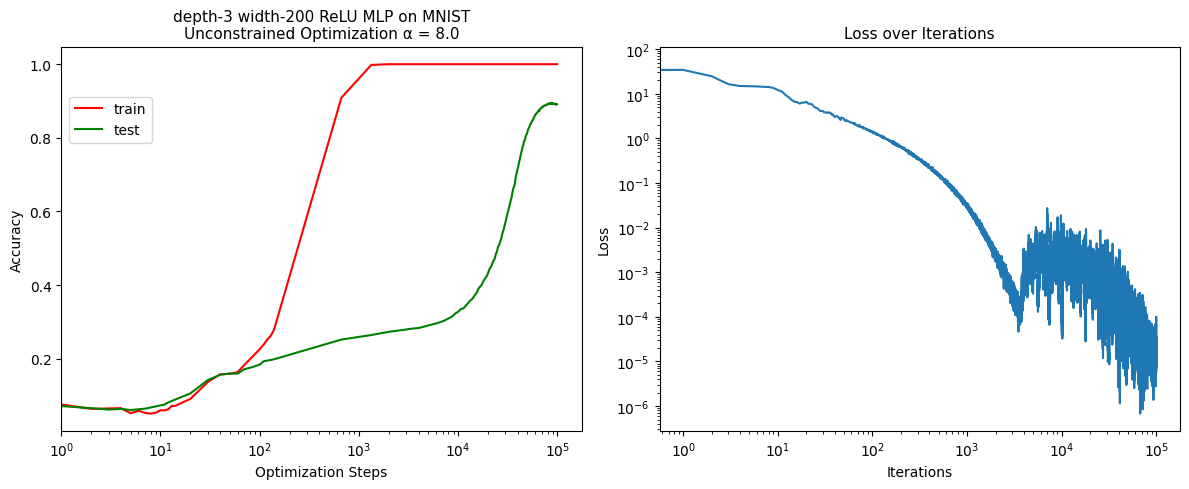

In [18]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_2
ax1.plot(log_steps, train_accuracies, color='red', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:])

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norms = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Pure preconditioning 

Now we run with pure preconditioning; and see the reduction in grokking; 

In [38]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)

# @markdown Number of epochs with no improvement after which learning rate will be reduced:
PATIENCE = 10  # @param{type:"integer"}
# @markdown Number of epochs to wait before resuming normal operation after the learning rate reduction:
COOLDOWN = 0  # @param{type:"integer"}
# @markdown Factor by which to reduce the learning rate:
FACTOR = 0.5  # @param{type:"number"}
# @markdown Relative tolerance for measuring the new optimum:
RTOL = 1e-4  # @param{type:"number"}
# @markdown Number of iterations to accumulate an average value:
ACCUMULATION_SIZE = 200

opt = optax.chain(
    optax.sgd(5e-4),
    # optax.contrib.reduce_on_plateau(
    #     patience=PATIENCE,
    #     cooldown=COOLDOWN,
    #     factor=FACTOR,
    #     rtol=RTOL,
    #     accumulation_size=ACCUMULATION_SIZE,
    #     min_scale=1e-5,
    # )
)
state = create_train_state(rng, model, learning_rate=1e-2, initialization_scale=initialization_scale, 
                           optimizer=opt)

output_lm_1 = train_mnist_precond(model, state, optimization_steps=10_000, lamb=1e-1, log_freq=100)



Custom optimizer


  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)

# @markdown Number of epochs with no improvement after which learning rate will be reduced:
PATIENCE = 10  # @param{type:"integer"}
# @markdown Number of epochs to wait before resuming normal operation after the learning rate reduction:
COOLDOWN = 0  # @param{type:"integer"}
# @markdown Factor by which to reduce the learning rate:
FACTOR = 0.5  # @param{type:"number"}
# @markdown Relative tolerance for measuring the new optimum:
RTOL = 1e-4  # @param{type:"number"}
# @markdown Number of iterations to accumulate an average value:
ACCUMULATION_SIZE = 200

opt = optax.chain(
    optax.sgd(5e-3),
    # optax.contrib.reduce_on_plateau(
    #     patience=PATIENCE,
    #     cooldown=COOLDOWN,
    #     factor=FACTOR,
    #     rtol=RTOL,
    #     accumulation_size=ACCUMULATION_SIZE,
    #     min_scale=1e-5,
    # )
)
state = create_train_state(rng, model, learning_rate=None, initialization_scale=initialization_scale, optimizer=opt)

output_lm_1 = train_mnist_precond(model, state, optimization_steps=50_000)



In [ ]:
rng = jax.random.PRNGKey(1)
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, lr, initialization_scale=initialization_scale, optimizer='sgd')

output_lm_2 = train_mnist_precond(model, state, optimization_steps=50_000)


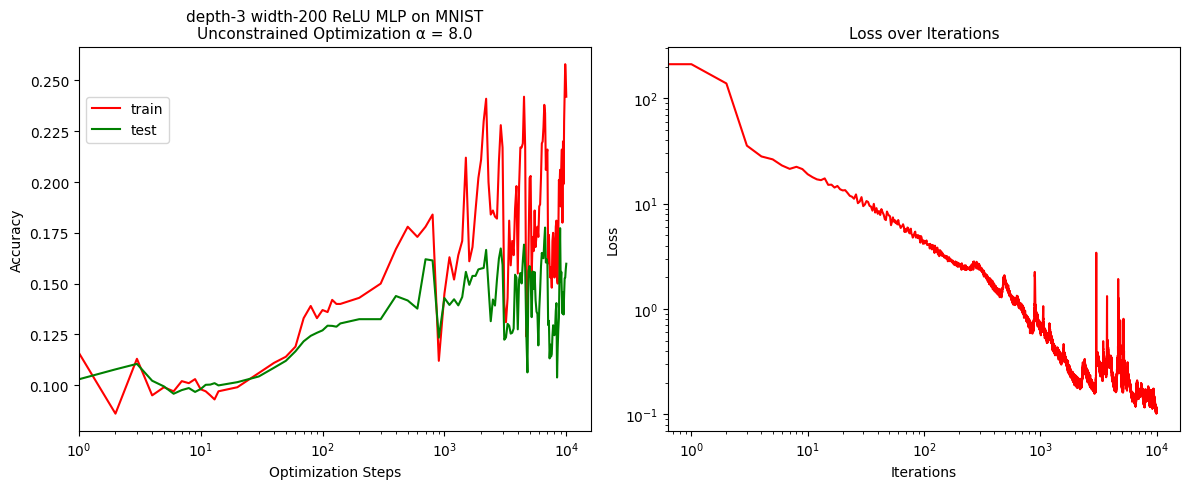

In [30]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norm = output_lm_1
ax1.plot(log_steps, train_accuracies, color='red', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:], color='red')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='blue', label='train')
# ax1.plot(log_steps, test_accuracies, color='blue', label='test')
# ax2.loglog(losses[:])


# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_2
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Try Adam first, before LM 

This is the standard technique

In [31]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, learning_rate=lr, 
                           initialization_scale=initialization_scale, optimizer='adamw')

output_temp = train_mnist_noprecond(model, state, optimization_steps=1_000, log_freq=100)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [32]:
state = MyTrainState.create(
    apply_fn=output_temp[-2].apply_fn,
    params=output_temp[-2].params,
    tx=optax.sgd(lr * .1))

output_temp_1 = train_mnist_precond(model, state, optimization_steps=10_000)

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

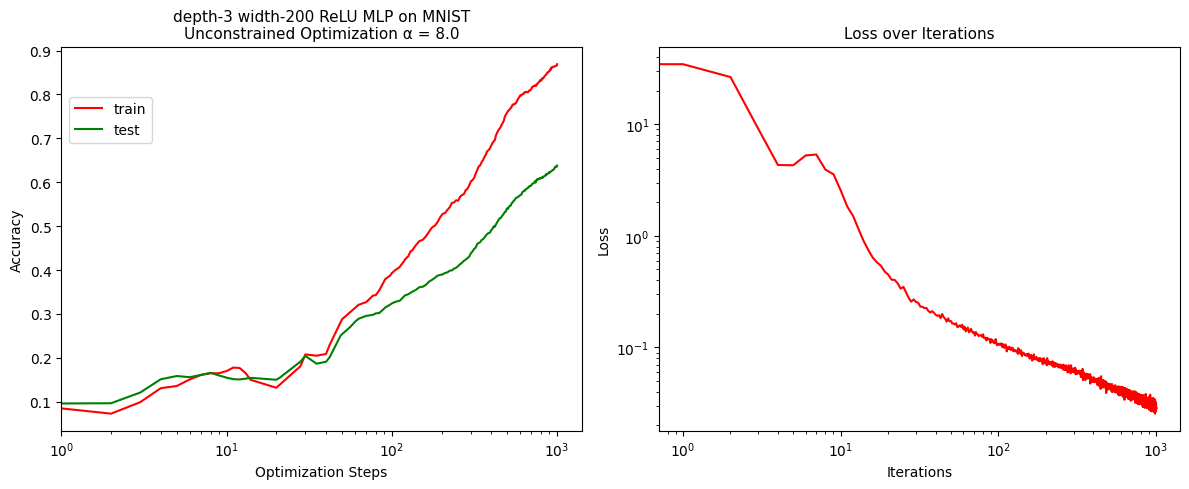

In [139]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state, norm = output_temp
ax1.plot(log_steps, train_accuracies, color='red', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:], color='red')

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='blue', label='train')
# ax1.plot(log_steps, test_accuracies, color='blue', label='test')
# ax2.loglog(losses[:])


# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_2
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Seems preconditioning is very difficult to converge with SGD 

Try with line search instead? Line search seems to do pretty well; but missing that last bit of "OOMPF" on test data. 

In [ ]:
def f(x):
    if i > 300:
        return 1e-4
    else: 
        return 1e-3

In [45]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
tx = optax.chain(
    optax.sgd(1),
    optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
)

state = create_train_state(rng, model, lr, initialization_scale=initialization_scale, optimizer=tx)

output_lm_linesearch_1 = train_mnist_precond(model, state, optimization_steps=10_000, log_freq=150, lamb=1e-3)



Custom optimizer


  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [41]:
# Create model
rng = jax.random.PRNGKey(1)
model = MLP(depth=depth, width=width)
tx = optax.chain(
    optax.sgd(1),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
)

state = create_train_state(rng, model, lr, initialization_scale=initialization_scale, optimizer=tx)

output_lm_linesearch_2 = train_mnist_precond(model, state, optimization_steps=50_000)



Custom optimizer


  0%|          | 0/50000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for accuracy
train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_linesearch_1
ax1.plot(log_steps, train_accuracies, color='green', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:])

train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_adamw_1
ax1.plot(log_steps, train_accuracies, color='blue', label='train')
ax1.plot(log_steps, test_accuracies, color='blue', label='test')
ax2.loglog(losses[:])


train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_2
ax1.plot(log_steps, train_accuracies, color='red', label='train')
ax1.plot(log_steps, test_accuracies, color='red', label='test')
ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Finally, line search with lm + Adam at the end ... 

In [33]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
tx = optax.chain(
    optax.sgd(1),
    optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
)

state = create_train_state(rng, model, lr, initialization_scale=initialization_scale, optimizer=tx)

output_lm_linesearch_w_adam_ls_1 = train_mnist_precond(model, state, optimization_steps=500)

state = MyTrainState.create(
    apply_fn=output_lm_linesearch_w_adam_ls_1[-1].apply_fn,
    params=output_lm_linesearch_w_adam_ls_1[-1].params,
    tx=optax.adamw(lr, weight_decay=weight_decay))
output_lm_linesearch_w_adam_adam_1 = train_mnist_noprecond(model, state, optimization_steps=20_000)


Custom optimizer


  0%|          | 0/500 [00:00<?, ?it/s]

AttributeError: 'list' object has no attribute 'apply_fn'

In [105]:
# Create model
rng = jax.random.PRNGKey(0)
model = MLP(depth=depth, width=width)
tx = optax.chain(
    optax.sgd(1),
    optax.scale_by_backtracking_linesearch(max_backtracking_steps=15, decrease_factor=.5)
)

state = create_train_state(rng, model, lr, initialization_scale=initialization_scale, optimizer=tx)

output_lm_linesearch_w_adam_ls_1 = train_mnist_precond(model, state, optimization_steps=500)

state = MyTrainState.create(
    apply_fn=output_lm_linesearch_w_adam_ls_1[-1].apply_fn,
    params=output_lm_linesearch_w_adam_ls_1[-1].params,
    tx=optax.adamw(lr, weight_decay=weight_decay))
output_lm_linesearch_w_adam_adam_1 = train_mnist_noprecond(model, state, optimization_steps=20_000)


Custom optimizer


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

In [107]:
print([type(x) for x in output_lm_linesearch_w_adam_ls_1[0:-1]])
# output_lm_linesearch_w_adam_adam_1

agg = [x + y for (x, y) in zip(output_lm_linesearch_w_adam_ls_1[0:-1], 
                               output_lm_linesearch_w_adam_adam_1[0:-1])]

[<class 'list'>, <class 'list'>, <class 'list'>, <class 'list'>, <class 'list'>, <class 'list'>]


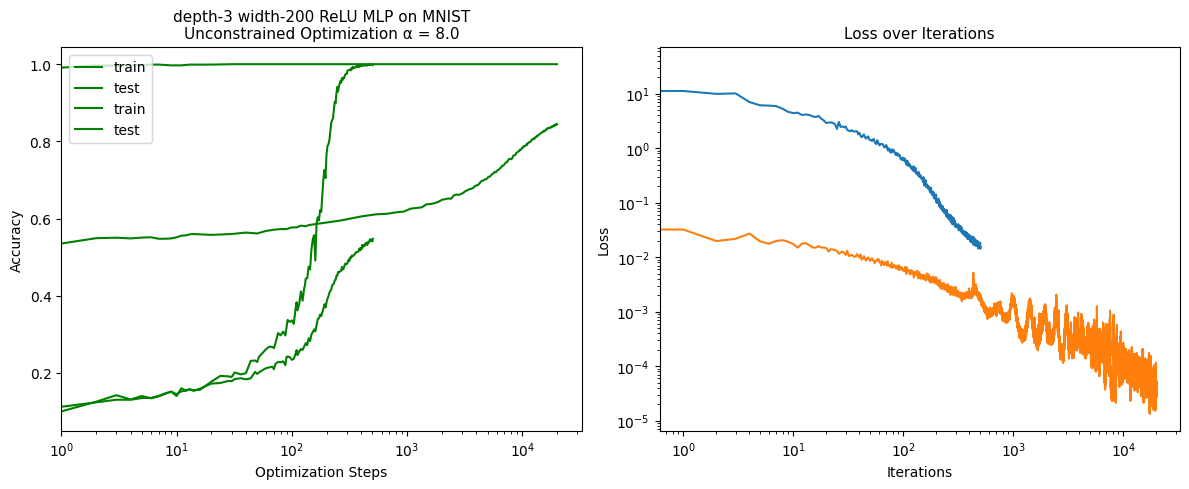

In [109]:
# Create a figure with 1 row and 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses = output_lm_linesearch_w_adam_ls_1[0:-1]
ax1.plot(log_steps, train_accuracies, color='green', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:])

train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses = output_lm_linesearch_w_adam_adam_1[0:-1]
ax1.plot(log_steps, train_accuracies, color='green', label='train')
ax1.plot(log_steps, test_accuracies, color='green', label='test')
ax2.loglog(losses[:])



# First subplot for accuracy
# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_linesearch_1
# ax1.plot(log_steps, train_accuracies, color='green', label='train')
# ax1.plot(log_steps, test_accuracies, color='green', label='test')
# ax2.loglog(losses[:])

# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_adamw_1
# ax1.plot(log_steps, train_accuracies, color='blue', label='train')
# ax1.plot(log_steps, test_accuracies, color='blue', label='test')
# ax2.loglog(losses[:])


# train_losses, test_losses, train_accuracies, test_accuracies, log_steps, losses, state = output_lm_2
# ax1.plot(log_steps, train_accuracies, color='red', label='train')
# ax1.plot(log_steps, test_accuracies, color='red', label='test')
# ax2.loglog(losses[:])

ax1.set_xscale('log')
ax1.set_xlim(1, None)
ax1.set_xlabel("Optimization Steps")
ax1.set_ylabel("Accuracy")
ax1.legend(loc=(0.015, 0.75))
ax1.set_title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)

ax2.set_xlabel("Iterations")
ax2.set_ylabel("Loss")
ax2.set_title("Loss over Iterations", fontsize=11)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()